# Repaso: ecuaciones diferenciales y métodos de integración numérica

Este notebook es una introducción a las ecuaciones diferenciales y la integración en el tiempo. Vamos a ver con calma **qué es una ecuación diferencial**, **de dónde sale el método de Euler**, **cómo elegir el paso de integración $dt$**, y una introducción a **Runge-Kutta de orden 4 (RK4)**, que es el método que más se usa en la práctica.

## Setup

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# Ecuaciones diferenciales en 1D

## 1. ¿Qué es una ecuación diferencial?

Una ecuación diferencial como

$$\dot{x} = \frac{dx}{dt} = f(x, t)$$

**no te dice cuánto vale $x$.** Te dice **a qué velocidad cambia** $x$ en cada instante, en función de dónde está parada la variable ahora mismo (y a veces del tiempo $t$ también). Es una regla *local*: "si estás en este punto, te movés así de rápido y en esta dirección".

Para reconstruir la función completa $x(t)$ a partir de esa regla local, necesitás dos ingredientes:

1. **Una condición inicial**: dónde arranca todo, $x(t_0) = x_0$. En el caso de una neurona, típicamente el potencial de membrana en reposo.
2. **Integrar**: ir acumulando esos cambios infinitesimales, paso a paso, arrancando desde $x_0$.

Eso es literalmente lo que significa **"resolver" o "integrar"** una ecuación diferencial: reconstruir la trayectoria completa a partir de saber, en cada punto, hacia dónde y qué tan rápido se mueve.

El ejemplo más sencillo es pensar en un auto que se mueve a 100 km/h. Si partimos del km 0, en una hora vamos a estar en el km 100, en 2 en el 200 y así sucesivamente. Si lo pensamos bien, lo que estamos haciendo es integrar la siguiente **ecuación diferencial ordinaria** (EDO) en el tiempo:

$$\dot x(t) = 100 \frac{km}{h} $$

ya que preguntarnos en dónde va a estar el auto en una hora equivale a resolver

$$x(1 hr) = \int_{t_0=0hr}^{t_f=1hr} 100 \frac{km}{hr} dt =   100 \frac{km}{hr} \times 1 hr$$

De forma general, en cualquier caso con derivada temporal (velocidad) constante, integrar la ecuación es equivalente a multiplicar la derivada por el tiempo transcurrido:

$$x(t) = \int_{t_0}^{t} v dt = v(t-t_0) \equiv vt + x_0$$

Un ejemplo como este es fácil, pero en general, la cosa se complica. Algunas EDOs se pueden resolver con álgebra pura (solución *analítica* — es lo que vamos a usar más abajo como referencia, con el ejemplo de la membrana pasiva). Pero en general (y más que nada en neurociencia, donde tenemos ecuaciones difíciles como la de Hodgkin–Huxley) no hay una fórmula cerrada, y ahí es donde entran los métodos **numéricos**, como Euler o Runge-Kutta. De forma resumida, estos métodos hacen el *trabajo sucio* por nosotros, devolviendonos la evolución de nuestras variables en el tiempo sin necesidad de hacer ninguna cuenta.

En todos los modelos de la práctica (membrana pasiva, Hodgkin–Huxley, LIF, Izhikevich) vas a encontrar la misma estructura $\dot x = f(x,t)$, y siempre los vamos a integrar de la misma manera: dando pasos discretos en el tiempo.

## 2. El método de Euler

Partimos de la definición de derivada y la vamos despejando:

$$\dot{x} = \frac{dx}{dt}$$

Esto es solo notación: $\dot{x}$ *es* la velocidad de cambio de $x$.

$$dx = \dot{x}\, dt$$

Multiplicamos ambos lados por $dt$. Esto dice: "el cambio en $x$ durante un intervalo de tiempo muy chico $dt$ es, aproximadamente, la velocidad por el tiempo transcurrido" — la misma lógica que "distancia = velocidad × tiempo", válida mientras $dt$ sea lo bastante chico como para que la velocidad no cambie mucho en el medio.

$$x(t_i) - x(t_{i-1}) = \dot{x}(t_{i-1})\, dt$$

Acá está la aproximación clave de Euler: usamos la velocidad **evaluada en el instante anterior** $t_{i-1}$ (que ya conocemos) como si fuera constante durante todo el paso $dt$. Solo sería exacta si $dt \to 0$; cuanto más chico el $dt$, mejor la aproximación (pero más pasos hay que calcular).

$$x(t_i) = x(t_{i-1}) + \dot{x}(t_{i-1})\, dt$$

Y esto ya es una **receta operativa**: si conocés $x$ en el paso anterior, y sabés calcular $\dot{x}$ ahí (con la ecuación diferencial del modelo que sea), podés calcular $x$ en el paso siguiente. Repitiendo esto muchas veces desde la condición inicial, se reconstruye toda la curva $x(t)$.

En código, esto siempre tiene la misma forma:

```python
for i in range(1, len(t)):
    derivada = ...calculada con el valor anterior, x[i-1]...
    x[i] = x[i-1] + derivada * dt
```

### Un ejemplo para trabajar: la membrana pasiva

Vamos a usar la misma ecuación de la membrana pasiva que en la práctica principal, así que las conclusiones de este repaso valen directamente para lo que sigue después:

$$C_m \frac{dV}{dt} = -g_L (V - E_L) + I$$

Usamos los mismos parámetros de fuga que en la práctica:

In [88]:
Cm = 1.0     # uF/cm^2
gL = 0.3     # mS/cm^2
EL = -54.4   # mV
I = 1.       # mV

tau_m = Cm / gL
print(f"tau_m = {tau_m:.2f} ms")

tau_m = 3.33 ms


La ventaja de este ejemplo es que, ante un escalón de corriente, tiene una **solución analítica exacta** (una exponencial) contra la cual podemos comparar la solución numérica:

$$V(t) = V_\infty + (V_0 - V_\infty)\, e^{-t/\tau_m}, \qquad V_\infty = E_L + \frac{I}{g_L}$$

Esto nos va a servir como "vara" para medir qué tan buena es la aproximación de Euler.

In [89]:
def integrador_euler(dt, t_max=20.0, I=I, V0=EL):
    t = np.arange(0, t_max, dt)
    V = np.zeros_like(t)
    V[0] = V0
    for i in range(1, len(t)):
        dV = (-gL * (V[i-1] - EL) + I) / Cm
        V[i] = V[i-1] + dV * dt
    return t, V

def solucion_analitica(t, I=I, V0=EL):
    V_inf = EL + I / gL
    return V_inf + (V0 - V_inf) * np.exp(-t / tau_m)

## 3. ¿Cómo elegimos el paso de integración $dt$?

La aproximación de Euler solo es buena si $\dot x$ no cambia mucho durante un paso $dt$. Eso depende de qué tan rápido evoluciona el sistema (acá, depende de $\tau_m$). Como referencia rápida: $\tau_m$ es el tiempo característico del sistema (nos dice que tan rápido reacciona la neurona), por lo tanto, para integrar adecuadamente la ecuación con Euler necesitamos una buena resolución temporal, particularmente una que sea una fracción chica de $\tau_m$ (tipicamente usar $dt \sim \tau_m / 10$ es más que suficiente). Si $dt$ se acerca a $\tau_m$ o lo supera, la aproximación se rompe.

Veamos esto directamente: simulemos la misma respuesta con varios valores de $dt$, cada vez más chicos, y comparemos contra la solución analítica.

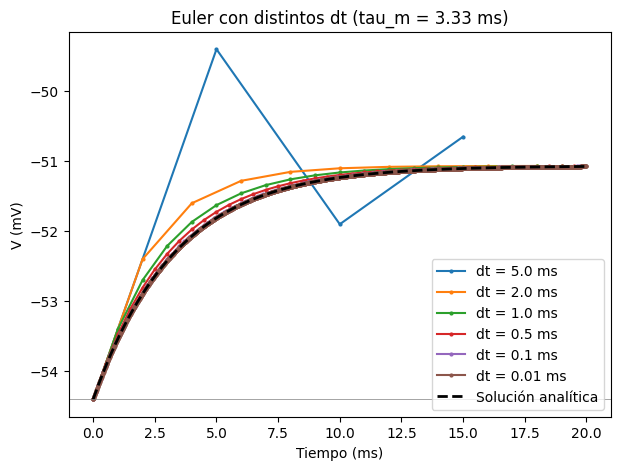

In [90]:
dts = [5.0, 2.0, 1.0, 0.5, 0.1, 0.01]  # ms

plt.figure(figsize=(7, 5))

for dt in dts:
    t, V = integrador_euler(dt)
    plt.plot(t, V, marker='o', ms=2, label=f'dt = {dt} ms')

t_fino = np.linspace(0, 20, 1000)
plt.plot(t_fino, solucion_analitica(t_fino), 'k--', lw=2, label='Solución analítica')


plt.axhline(EL, color='gray', lw=0.5)
plt.xlabel('Tiempo (ms)')
plt.ylabel('V (mV)')
plt.title(f'Euler con distintos dt (tau_m = {tau_m:.2f} ms)')
plt.legend()
plt.show()

Con $\tau_m \approx 3.3$ ms, se ve el patrón esperado:

- Con $dt = 5$ ms (**mayor** que $\tau_m$) la curva no solo se aleja de la analítica: **oscila y se dispara** por encima y por debajo del valor de equilibrio. Esto no es un detalle menor, es una **inestabilidad numérica**: cuando $dt$ es demasiado grande comparado con la escala de tiempo del sistema, Euler puede "pasarse de largo" en cada paso y el error se amplifica en vez de achicarse.
- A medida que $dt$ baja (2, 1, 0.5 ms) la curva se va acercando a la analítica, pero todavía se nota diferencia, sobre todo al principio (donde $V$ cambia más rápido).
- Con $dt = 0.1$ ms y $dt = 0.01$ ms las curvas prácticamente se superponen con la analítica y **entre sí** — a partir de ahí, achicar más el paso no cambia visiblemente el resultado.

Esa es la idea central para elegir $dt$: no hay que adivinar. **Se achica el paso hasta que el resultado deja de cambiar** (dentro de la precisión que nos importa). A eso se llama chequear la **convergencia**. Podemos hacerlo cuantitativo midiendo el error contra la solución analítica:


In [91]:
print(f"{'dt (ms)':>8} | {'error máximo vs. analítica (mV)':>32}")
for dt in dts:
    t, V = integrador_euler(dt)
    error = np.max(np.abs(V - solucion_analitica(t)))
    print(f"{dt:>8} | {error:>32.4f}")

 dt (ms) |  error máximo vs. analítica (mV)
     5.0 |                           2.4104
     2.0 |                           0.4960
     1.0 |                           0.2119
     0.5 |                           0.0981
     0.1 |                           0.0186
    0.01 |                           0.0018


El error baja de forma pareja a medida que $dt$ se achica (Euler tiene error proporcional a $dt$: si achicás el paso a la mitad, el error también se achica aproximadamente a la mitad). En algún punto el error se vuelve chico comparado con lo que nos importa (por ejemplo, mucho menor al mV si estamos mirando voltajes de membrana) y ahí es razonable quedarse con ese $dt$.

**En resumen, para elegir $dt$ en la práctica:**

1. Arrancá con un $dt$ bastante menor a la escala de tiempo más rápida del sistema (una fracción de $\tau_m$, o del tiempo característico que corresponda al modelo).
2. Corré la simulación con ese $dt$ y con uno más chico (por ejemplo, la mitad).
3. Si el resultado no cambia de forma apreciable, ese $dt$ ya alcanza. Si cambia, seguí achicando hasta que deje de cambiar.
4. Tené en cuenta el costo: un $dt$ más chico significa más pasos y más tiempo de cómputo, así que en la práctica se busca el $dt$ más grande que todavía da un resultado convergido — no el más chico posible.
5. Si ves oscilaciones o valores que se disparan (como con $dt=5$ ms arriba), es una señal inequívoca de que $dt$ es demasiado grande para ese sistema — no una cuestión de precisión fina, sino de inestabilidad franca.

Esto vale para cualquier modelo de la práctica: cuanto más rápida sea la dinámica que querés capturar (por ejemplo, la subida del potencial de acción en Hodgkin-Huxley, mucho más rápida que $\tau_m$), más chico va a tener que ser $dt$ para que Euler la siga bien.

## 4. Runge-Kutta de orden 4 (RK4)

Euler tiene una limitación de fondo: usa **una sola** evaluación de la derivada (al principio del paso) y la asume constante durante todo el intervalo. Es una aproximación razonable, pero grosera.

La familia de métodos de **Runge-Kutta** mejora esto evaluando la derivada en **varios puntos dentro del mismo paso** y combinándolos en un promedio pesado, en vez de quedarse con una sola muestra. El más usado en la práctica es **RK4** (orden 4), que evalúa la derivada 4 veces por paso:

$$
\begin{aligned}
k_1 &= f(x_{i-1}, t_{i-1}) &&\text{(pendiente al principio del paso)}\\
k_2 &= f\left(x_{i-1} + \tfrac{dt}{2}k_1,\ t_{i-1} + \tfrac{dt}{2}\right) &&\text{(pendiente a mitad de camino, usando } k_1\text{)}\\
k_3 &= f\left(x_{i-1} + \tfrac{dt}{2}k_2,\ t_{i-1} + \tfrac{dt}{2}\right) &&\text{(pendiente a mitad de camino, usando } k_2\text{)}\\
k_4 &= f\left(x_{i-1} + dt\,k_3,\ t_{i-1} + dt\right) &&\text{(pendiente al final del paso, usando } k_3\text{)}
\end{aligned}
$$

$$x(t_i) = x(t_{i-1}) + \frac{dt}{6}\big(k_1 + 2k_2 + 2k_3 + k_4\big)$$

La idea intuitiva: en vez de "mirar" la dirección solo al arrancar el paso (Euler) y caminar en línea recta con esa dirección todo el tramo, RK4 "espía" la dirección en varios puntos del camino (incluyendo puntos intermedios estimados con las pendientes anteriores) y promedia esas direcciones dándole más peso a las del medio. Eso compensa mucho mejor los cambios de dirección dentro del paso, así que el error por paso es muchísimo menor que en Euler.

Yendo a los números, uno puede hacer la cuenta y estimar el error global que acumulará el integrador en un intervalo de tiempo $T$ en función del paso temporal $dt$. Para cada caso tenemos:

- **Euler**: Error global escala como $dt$
- **RK4**: Error global escala como $dt^4$

Esto quiere decir que si reducimos nuestro $dt$ a la mitad ($dt/2$), en Euler el error acumulado se reducirá a la mitad, mientras que en RK4 el error se desplomará y será 16 veces menor ($2^4$).


Por eso, en la práctica (investigación, software de simulación, etc.) **RK4** (o variantes adaptativas basadas en él, como las que usa `scipy.integrate.solve_ivp` por default) es el método que más se usa para integrar ecuaciones diferenciales, no Euler.

In [92]:
def f(V, t):
  return (-gL * (V - EL) + I) / Cm

# Esta función integra numéricamente nuestra derivada usando el método RK4.
# Fijense que el primer input es una funcion f. En nuestro caso puede ser
# la tasa de cambio del potencial de membrana, pero el método es suficientemente
# general como para que utilicen cualquier otra ecuación diferencial (incluso
# con más de una variable!)

def integrador_rk4(f, dt, t_max=20.0, V0=EL):
    t = np.arange(0, t_max, dt)
    V = np.zeros_like(t)
    V[0] = V0
    for i in range(1, len(t)):
        k1 = f(V[i-1], t[i-1])
        k2 = f(V[i-1] + dt/2 * k1, t[i-1] + dt/2)
        k3 = f(V[i-1] + dt/2 * k2, t[i-1] + dt/2)
        k4 = f(V[i-1] + dt * k3, t[i-1] + dt)
        V[i] = V[i-1] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    return t, V

Comparemos Euler y RK4 con el **mismo** $dt$, grande (1 ms), contra la solución analítica:

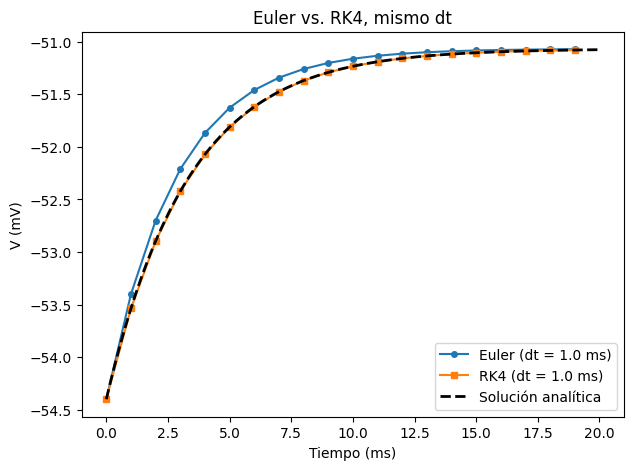

Error máximo Euler: 0.2119 mV
Error máximo RK4:   0.0001 mV


In [93]:
dt_grande = 1.0

t_e, V_e = integrador_euler(dt_grande)
t_r, V_r = integrador_rk4(f,dt_grande)

plt.figure(figsize=(7, 5))
plt.plot(t_e, V_e, 'o-', ms=4, label=f'Euler (dt = {dt_grande} ms)')
plt.plot(t_r, V_r, 's-', ms=4, label=f'RK4 (dt = {dt_grande} ms)')
plt.plot(t_fino, solucion_analitica(t_fino), 'k--', lw=2, label='Solución analítica')
plt.xlabel('Tiempo (ms)')
plt.ylabel('V (mV)')
plt.title('Euler vs. RK4, mismo dt')
plt.legend()
plt.show()

error_euler = np.max(np.abs(V_e - solucion_analitica(t_e)))
error_rk4 = np.max(np.abs(V_r - solucion_analitica(t_r)))
print(f"Error máximo Euler: {error_euler:.4f} mV")
print(f"Error máximo RK4:   {error_rk4:.4f} mV")

Con el mismo $dt$, RK4 queda visiblemente pegado a la curva analítica mientras Euler todavía se nota separado — y el error numérico lo confirma. Esa es la ventaja de RK4: para un mismo costo de paso, es mucho más preciso (o, mirado al revés, para una misma precisión, permite usar un $dt$ mucho más grande y ahorrar cómputo).

### Entonces, ¿por qué vamos a usar Euler en la práctica?

Porque es **más intuitivo**: la relación entre la ecuación diferencial y el código es directa y transparente ("tomo la pendiente actual y avanzo un poquito en esa dirección"), sin pasos intermedios que oscurezcan qué está pasando. Nuestro objetivo en esta práctica es entender la **dinámica biológica** de los modelos, no la integración numérica en sí. Por lo tanto, preferimos un método conceptualmente más simple, aunque en un proyecto de investigación real lo más probable es que termines usando RK4 o un método adaptativo en su lugar.

## Resumen

- Toda ecuación diferencial $\dot x = f(x,t)$ se integra numéricamente dando pasos chicos y recalculando la derivada en cada paso.
- **Euler** usa la derivada al principio del paso y la asume constante durante todo el intervalo. Es simple e intuitivo, pero su error es proporcional a $dt$.
- El paso $dt$ se elige por **convergencia**: se achica hasta que el resultado deja de cambiar de forma apreciable, comparado con la precisión que nos interesa (no hay que adivinar el valor "correcto").
- **RK4** evalúa la derivada 4 veces distintas dentro de cada paso y las combina, logrando mucha más precisión con el mismo $dt$. Es el método más usado en la práctica real, pero en este curso usamos Euler por su simplicidad conceptual.

## Bonus: El problema del paso fijo y la integración adaptativa

Hasta acá veníamos fijando el $dt$ a mano. Como vimos con Euler y RK4, elegir el $dt$ es un compromiso: si es muy grande, la simulación explota o acumula mucho error; si es muy chico, tarda una eternidad. Usar un paso fijo es como obligarte a mirar el camino y ajustar el volante del auto exactamente cada 10 metros, sin importar por dónde vayas. En una recta infinita es un desperdicio de tiempo, y en un camino de montaña lleno de curvas cerradas, te vas derecho a la banquina.  Para evitar este problema existen los integradores adaptativos. Funcionan como un conductor inteligente: el algoritmo va estimando el error que comete sobre la marcha. Si las variables del modelo cambian bruscamente (curvas), el algoritmo achica el $dt$ automáticamente para no perder precisión. Si el sistema entra en un régimen donde las variables cambian suavemente (recta), agranda el $dt$ para avanzar a pasos agigantados y ahorrar mucho tiempo de cómputo.

En la práctica real, rara vez programamos el integrador numérico desde cero. Usamos librerías ultra optimizadas que ya traen este control de errores resuelto. En Python, la herramienta por excelencia para esto es la función `solve_ivp` de `scipy.integrate`, que por defecto usa un método de la familia de Runge-Kutta de orden 4 y 5 combinados (RK45) para ir adaptando el paso.  

In [94]:
from scipy.integrate import solve_ivp

# IMPORTANTE: solve_ivp pide que la función de la ecuación diferencial tenga la firma f(t, x).
# En nuestro ejemplo de Euler y RK4 teníamos f(V, t), así que la redefinimos rápido:
def f_scipy(t, V):
    # Usamos los mismos parámetros de la membrana pasiva (gL, EL, I, Cm) de las celdas anteriores
    return (-gL * (V - EL) + I) / Cm

# Resolvemos usando el integrador adaptativo (RK45)
# Le pasamos la función, el intervalo de tiempo a integrar [0, t_max], y la condición inicial V0=EL en forma de lista[cite: 1]
solucion_adaptativa = solve_ivp(f_scipy, [0, 20.0], [EL])

# El objeto "solucion_adaptativa" tiene toda la info de la corrida. Lo que nos importa extraer es:
# .t -> Los instantes de tiempo exactos que el algoritmo ELIGIÓ evaluar
# .y -> El valor de las variables (en este caso el voltaje) en esos instantes
t_adaptativo = solucion_adaptativa.t
V_adaptativo = solucion_adaptativa.y[0]

print(f"¿La integración terminó bien?: {solucion_adaptativa.success}")
print(f"El algoritmo resolvió todo el intervalo en apenas {len(t_adaptativo)} pasos!")

¿La integración terminó bien?: True
El algoritmo resolvió todo el intervalo en apenas 6 pasos!


Fijate lo intuitivo que resulta ver esto gráficamente. Vamos a plotear exactamente en qué puntos de tiempo el algoritmo decidió frenar y hacer una evaluación para que el error global se mantenga siempre debajo de la tolerancia que trae por defecto:

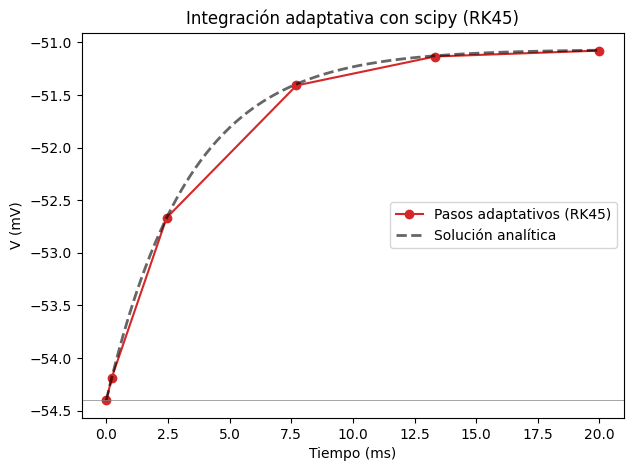

In [95]:
plt.figure(figsize=(7, 5))

# Graficamos los puntos reales elegidos por el integrador adaptativo
plt.plot(t_adaptativo, V_adaptativo, 'o-', ms=6, color='tab:red', label='Pasos adaptativos (RK45)')

# Comparamos con la solución analítica exacta (la exponencial) que usamos de referencia antes[cite: 1]
plt.plot(t_fino, solucion_analitica(t_fino), 'k--', lw=2, alpha=0.6, label='Solución analítica')

plt.axhline(EL, color='gray', lw=0.5) #[cite: 1]
plt.xlabel('Tiempo (ms)')
plt.ylabel('V (mV)')
plt.title('Integración adaptativa con scipy (RK45)')
plt.legend()
plt.show()

Al principio del escalón de corriente, cuando la membrana recién empieza a cargarse y el voltaje sube muy rápido (es decir, en el transitorio dictado por el tiempo característico $\tau_m$[cite: 1]), el algoritmo dio pasitos más cortos y seguidos para capturar bien la curva.

A medida que el voltaje se va acercando a su asintota (el estado estacionario $V_\infty$[cite: 1]) y la derivada empieza a valer casi cero, el integrador se da cuenta de que ya no hay peligro de acumular errores por cambios bruscos. En ese momento, agranda radicalmente el $dt$, ¡y te resuelve los últimos milisegundos de la simulación dando apenas dos o tres pasos gigantes!

# Ecuaciones diferenciales en N dimensiones

*Disclaimer: para entender esta parte conviene ya haber visto el repaso de vectores y matrices*

Lo bueno de esta segunda parte es que si entendieron integración numérica en 1 dimensión, la entienden para muchas dimensiones. Esto es porque es básicamente aplicar el mismo método pero usando una función `f(x,t)` que recibe un vector $\vec x \in \mathcal R^N$ (no un escalar) y devuelve un vector de derivadas (es decir, una derivada $\dot x_i$ para cada variable $x_i$, con $i=1,...,N$).

La motivación es clara: en la realidad biológica, rara vez nos importa una sola variable aislada. Por ejemplo:
 - Un modelo complejo de una neurona: El clásico modelo de Hodgkin-Huxley no tiene solo el voltaje $V$, sino también las variables de compuerta de los canales iónicos ($m, h, n$). Es un sistema de 4 dimensiones acoplado.

 - Una red neuronal: Imaginate un circuito donde muchas neuronas interactúan entre sí pasándose corriente o actividad a través de sinapsis. Si tenemos $N$ neuronas, tenemos un sistema de $N$ dimensiones.

 Si agrupamos el estado de todas esas variables en un solo vector $\vec{x}$, la ecuación diferencial genérica sigue siendo la misma:

 $$\dot{\vec{x}} = f(\vec{x}, t)$$

 Y la receta de Euler (o cualquier otro integrador) es idéntica, solo que ahora suma vectores:

 $$\vec{x}(t_i) = \vec{x}(t_{i-1}) + \vec{f}(\vec{x}_{i-1}, t_{i-1})\, dt$$

 En Python, gracias a que NumPy maneja arreglos multidimensionales (arrays), no hace falta escribir un ciclo for para cada neurona. Escribís la ecuación de forma vectorial y NumPy hace las cuentas elemento a elemento.

 Veamos un ejemplo súper intuitivo: una red chiquita de dos neuronas que interactúan. Una es excitatoria y la otra inhibitoria:

 $$
  \begin{matrix}
  \tau \dot V_1 = -V_1 - W_{0} V_2 + I_{ext}\\
  \tau \dot V_2 = -V_2 + W_{0} V_1 + I_{ext}
  \end{matrix}
 $$

 con $W_{0}>0$. En definitiva, podemos resumir estas ecuaciones diferenciales como un sistema matricial:

 $$\dot{\vec V} = f(\vec V,t)$$

 donde

 $$f(\vec V, t) = \mathbf W \cdot \vec V, \quad \mathbf W = \left(\begin{matrix}-1 && -W_0\\W_0 && 1\end{matrix}\right), \quad \vec V = \left(\begin{matrix}V_1\\V_2\end{matrix}\right)$$

In [96]:
# Definimos una red de 2 neuronas acopladas: N1 (Excitatoria) y N2 (Inhibitoria)
# W es la matriz de conectividad (pesos sinápticos). W[i, j] es el peso de la neurona j a la neurona i.
W = np.array([[ 0.0, -1.0],   # N2 inhibe a N1
              [ 1.0,  0.0]])  # N1 excita a N2

tau = 5.0 # ms, constante de tiempo para ambas
I_ext = np.array([1.5, 0.0]) # Le inyectamos una corriente externa constante SOLO a N1

# Nuestra función de derivada ahora recibe un VECTOR V = [V1, V2]
def red_neuronal(t, V):
    # La tasa de cambio ahora es vectorial.
    # Usamos np.dot para multiplicar la matriz W por el vector de estado V.
    # Fijate que la pinta de la ecuación es idéntica a la 1D, ¡pero opera en N dimensiones en simultáneo!
    dVdt = (-V + np.dot(W, V) + I_ext) / tau
    return dVdt

# Condición inicial: pasamos una lista con el estado inicial de cada variable.
# Ambas arrancan en el reposo absoluto (0, 0)
V0 = [0.0, 0.0]

# Le tiramos el problema a scipy, que se banca sistemas N-dimensionales de taquito
solucion_nd = solve_ivp(red_neuronal, [0, 50], V0, max_step=0.5)

# solucion_nd.y ahora es una matriz donde cada fila es la evolución temporal de una variable
V1 = solucion_nd.y[0]
V2 = solucion_nd.y[1]

Al plotear el resultado, vas a ver cómo el sistema se auto-regula. La corriente externa levanta la actividad de la neurona excitatoria (N1). Como N1 excita a N2, la inhibitoria también empieza a subir. Pero al subir, N2 inhibe a N1, haciéndola bajar... lo que genera un ciclo de retroalimentación que termina en una oscilación amortiguada.

¡Resolvimos la dinámica emergente de una red neuronal acoplada cambiando literalmente tres líneas de código!

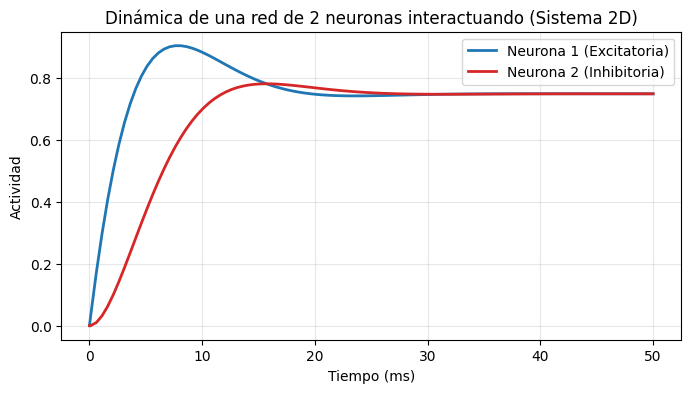

In [97]:
plt.figure(figsize=(8, 4))

plt.plot(solucion_nd.t, V1, lw=2, color='tab:blue', label='Neurona 1 (Excitatoria)')
plt.plot(solucion_nd.t, V2, lw=2, color='tab:red', label='Neurona 2 (Inhibitoria)')

plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad')
plt.title('Dinámica de una red de 2 neuronas interactuando (Sistema 2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Dinámica Lineal vs. No Lineal y Puntos Fijos

Ahora que sabemos cómo resolver las ecuaciones en la computadora, vale la pena frenar un segundo a pensar en qué tipo de dinámicas estamos simulando. En el fondo, el comportamiento de cualquier sistema dinámico (sea una membrana pasiva, un péndulo o una red de neuronas) depende fuertemente de si sus ecuaciones son lineales o no lineales.

- **Sistemas Lineales**: Son aquellos donde las variables cambian de forma directamente proporcional a su estado. Tienen la propiedad de superposición (la suma de dos soluciones es también solución). Dinámicamente hablando, suelen ser bastante "obedientes" o aburridos: o decaen exponencialmente hacia un único punto de equilibrio (como el voltaje de la membrana pasiva volviendo a $E_L$), o crecen al infinito, u oscilan eternamente como un resorte ideal.
- **Sistemas No Lineales**: Acá es donde la cosa se pone interesante. Al introducir funciones no lineales (cuadrados, cubos, exponenciales, o la típica función sigmoidea/ReLU de activación de una neurona), el sistema pierde la superposición y gana una riqueza de comportamientos brutal: puede tener múltiples estados de equilibrio, ciclos límite (oscilaciones auto-sostenidas, como los disparos de un potencial de acción), o incluso caos.

El concepto fundamental para entender cualquier sistema, lineal o no, es el de **punto fijo** (o estado estacionario).

Matemáticamente, un punto fijo $x^*$ es un estado donde la derivada se anula:

$$\dot{x} = f(x^*) = 0$$

Físicamente, significa que si el sistema llega a ese estado $x^*$, se queda quieto ahí para siempre porque su velocidad de cambio es cero.

En la neurociencia teórica, los puntos fijos son el corazón del procesamiento de información. Por ejemplo, vamos a ver en clase que una forma de modelar como una red puede almacenar distintas memorias es construyendo una matriz de conectividad que permita que estas memorias sean puntos fijos estables (atractores) del sistema. Cuando le presentás un patrón ruidoso o incompleto a la red, la dinámica natural hace que el sistema evolucione y "caiga" en ese punto fijo, recuperando la memoria original. Y si ampliamos la mirada más allá de puntos aislados, sistemas como las redes de atractores continuos se sostienen sobre la existencia de infinitos puntos fijos conectados (una variedad o manifold continua). Es justamente esta estructura de puntos fijos la que permite representar variables continuas en el cerebro de los mamíferos, dándole vida a los mapas espaciales.



### Ejemplo 1D

Para bajar esto a tierra, veamos el ejemplo más clásico de un sistema no lineal en 1D que tiene más de un punto fijo.

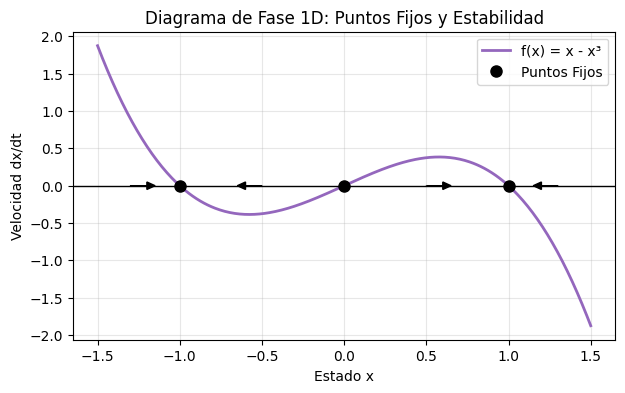

In [98]:
# Sistema no lineal: dx/dt = x - x^3
# Puntos fijos (donde dx/dt = 0):
# x - x^3 = x(1 - x^2) = 0  => x = 0, x = 1, x = -1

x = np.linspace(-1.5, 1.5, 400)
# Calculamos la derivada dx/dt para cada valor de x
dxdt = x - x**3

plt.figure(figsize=(7, 4))
plt.plot(x, dxdt, lw=2, color='tab:purple', label='f(x) = x - x³')

# Marcamos la línea del cero (donde la derivada se anula)
plt.axhline(0, color='black', lw=1)

# Marcamos los puntos fijos
plt.plot([-1, 0, 1], [0, 0, 0], 'ko', ms=8, label='Puntos Fijos')

# Agregamos flechas para mostrar hacia dónde "fluye" el sistema
# Si f(x) > 0, x crece (flecha a la derecha). Si f(x) < 0, x decrece (flecha a la izquierda)
plt.arrow(-1.3, 0, 0.1, 0, head_width=0.1, head_length=0.05, fc='k', ec='k')
plt.arrow(-0.5, 0, -0.1, 0, head_width=0.1, head_length=0.05, fc='k', ec='k')
plt.arrow(0.5, 0, 0.1, 0, head_width=0.1, head_length=0.05, fc='k', ec='k')
plt.arrow(1.3, 0, -0.1, 0, head_width=0.1, head_length=0.05, fc='k', ec='k')

plt.xlabel('Estado x')
plt.ylabel('Velocidad dx/dt')
plt.title('Diagrama de Fase 1D: Puntos Fijos y Estabilidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Mirando el gráfico (que se conoce como diagrama de fase en 1D), no hace falta integrar nada para saber qué va a pasar: Los puntos negros son los puntos fijos:

- $x=-1$,
- $x=0$
- $x=1$.

Ahí la curva corta el eje horizontal ($\dot{x}=0$).

- Si arrancás en un valor donde la curva está por encima del cero (ej: $x=0.5$), la derivada es positiva. Eso significa que $x$ crece, empujándote hacia la derecha (hacia el 1).

- Si arrancás donde la curva está por debajo del cero (ej: $x=1.2$), la derivada es negativa. $x$ decrece, empujándote hacia la izquierda (de vuelta al 1).

Como las flechas "apuntan" hacia el 1 y el -1, decimos que son puntos fijos estables (atractores). Si te alejás un poquito, el sistema te vuelve a empujar hacia ellos. En cambio, en $x=0$, las flechas apuntan hacia afuera. Es un punto fijo inestable: si arrancás exactamente en 0 te quedás ahí, pero ante la más mínima perturbación (ruido térmico, un pequeño error numérico), el sistema sale disparado hacia alguno de los otros dos **atractores**.

**Nota:** al gráfico de arriba se lo conoce como **diagrama de fase**

Podemos visualizar esto integrando numéricamente el sistema dadas distintas condiciones iniciales. El poder de este formalismo está en que ya podemos entender de forma cualitativa el comportamiento del sistema sin necesidad de integrar numéricamente las ecuaciones para muchas condiciones iniciales. Sin embargo, muchas veces está bueno hacerlo para verificar nuestra intuición!

<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1349/636107743.py:28: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Evolución temporal del sistema $\dot{x} = x - x^3$ (Integrado con RK4)')


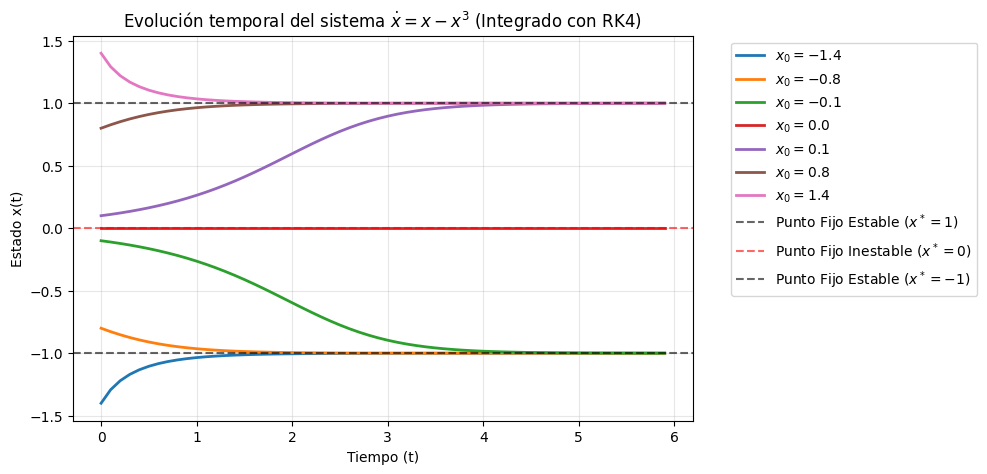

In [99]:
# Definimos la ecuación diferencial no lineal
# Tu integrador RK4 espera que la función reciba (estado, tiempo), así que usamos (x, t)
def f_nolineal(x, t):
    return x - x**3

# Parámetros de simulación
dt = 0.1
t_max = 6.0

# Elegimos un abanico de condiciones iniciales (por encima, por debajo y exactamente en los puntos fijos)
x0_list = [-1.4, -0.8, -0.1, 0.0, 0.1, 0.8, 1.4]

plt.figure(figsize=(8, 5))

# Integramos iterativamente para cada condición inicial usando RK4
for x0 in x0_list:
    # Reutilizamos integrador_rk4, pasando x0 a la variable V0
    t, x_t = integrador_rk4(f_nolineal, dt, t_max=t_max, V0=x0)
    plt.plot(t, x_t, lw=2, label=f'$x_0 = {x0}$')

# Trazamos líneas punteadas horizontales para marcar los puntos fijos teóricos
plt.axhline(1, color='black', linestyle='--', alpha=0.6, label='Punto Fijo Estable ($x^*=1$)')
plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Punto Fijo Inestable ($x^*=0$)')
plt.axhline(-1, color='black', linestyle='--', alpha=0.6, label='Punto Fijo Estable ($x^*=-1$)')

plt.xlabel('Tiempo (t)')
plt.ylabel('Estado x(t)')
plt.title('Evolución temporal del sistema $\dot{x} = x - x^3$ (Integrado con RK4)')
# Ponemos la leyenda afuera para no tapar las curvas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

### Ejemplo 2D

Cuando pasamos a dos dimensiones, el diagrama de fase se transforma en un plano de fase. En vez de una curva que nos dice si la variable sube o baja, ahora tenemos un campo vectorial: en cada punto $(x_1, x_2)$ evaluamos las derivadas simultáneamente y dibujamos una flecha (un vector). Esa flecha nos indica la dirección y la velocidad con la que el sistema se movería si estuviera parado exactamente ahí.

Vamos a visualizar un ejemplo clásico en neurociencia computacional: una red de dos neuronas con una función de activación sigmoidea (usaremos la tangente hiperbólica $\tanh$, muy común al estudiar modelos continuos y redes de Hopfield).

Le vamos a dar a la red la siguiente conectividad:
- Auto-excitación fuerte: Cada neurona se estimula a sí misma.
- Mutua inhibición: Cada neurona intenta apagar a la otra.

Esto genera una dinámica de competición (un mecanismo tipo Winner-Takes-All), lo que hace que el sistema sea fuertemente no lineal y biestable.


Matemáticamente, el sistema es muy parecido a la red de neurona excitatoria-inhibitoria lineal que vimos al principio

$$\dot{\vec V} = -\vec V + \mathbf M \cdot \tanh \left(\vec V\right)$$

¡Veamos cómo se ven los puntos fijos de esta red en 2D!

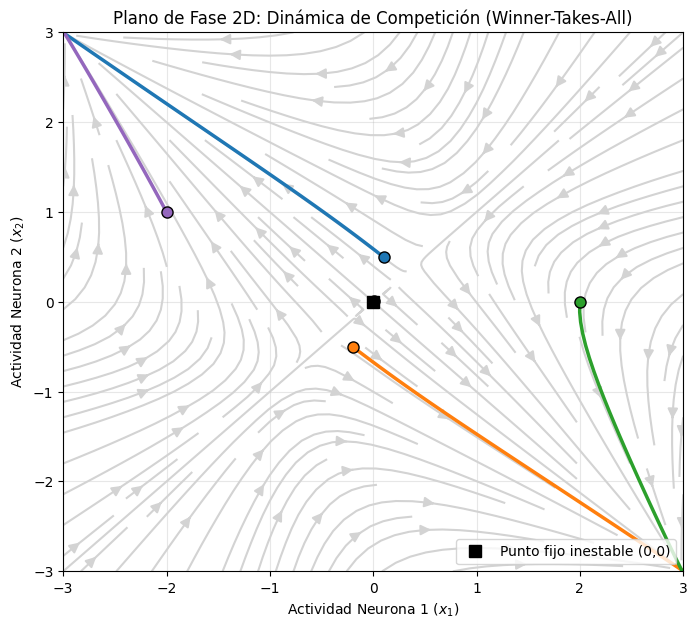

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Definimos la función de activación (sigmoide bipolar)
def activacion(x):
    return np.tanh(x)

# Matriz de pesos: W[0,0] y W[1,1] son auto-excitación; W[0,1] y W[1,0] mutua inhibición
W = np.array([[ 2.0, -1.0],
              [-1.0,  2.0]])

# Derivada del sistema 2D
def red_2d(t, V):
    # V es un vector de estado [x1, x2]
    # La ecuación vectorial es: dV/dt = -V + W * f(V)
    return -V + np.dot(W, activacion(V))

# === 1. ARMAMOS EL CAMPO VECTORIAL ===
# Creamos una grilla de puntos en el plano usando meshgrid
x_vals = np.linspace(-3, 3, 20)
y_vals = np.linspace(-3, 3, 20)
X1, X2 = np.meshgrid(x_vals, y_vals)

# Evaluamos la derivada en cada punto exacto de la grilla
# (Hacemos el cálculo de forma explícita para la grilla 2D)
dX1 = -X1 + W[0,0] * activacion(X1) + W[0,1] * activacion(X2)
dX2 = -X2 + W[1,0] * activacion(X1) + W[1,1] * activacion(X2)

plt.figure(figsize=(8, 7))

# streamplot dibuja las líneas de corriente fluyendo a través del campo vectorial
plt.streamplot(X1, X2, dX1, dX2, color='lightgray', linewidth=1.5, density=1.2, arrowsize=1.5)

# === 2. LARGAMOS ALGUNAS TRAYECTORIAS NUMÉRICAS ===
# Elegimos varias condiciones iniciales [x1_0, x2_0] para ver a dónde van a parar
condiciones_iniciales = [
    [ 0.1,  0.5], # Empieza ganando apenas la neurona 2
    [-0.2, -0.5], # Empiezan ambas negativas, la 2 más inhibida
    [ 2.0,  0.0],
    [-2.0,  1.0],
    [ 0.01, 0.01] # Justo al ladito del (0,0)
]

colores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:red']
t_span = [0, 10]

for V0, color in zip(condiciones_iniciales, colores):
    sol = solve_ivp(red_2d, t_span, V0, max_step=0.1)
    # Dibujamos la trayectoria
    plt.plot(sol.y[0], sol.y[1], lw=2.5, color=color)
    # Marcamos el punto de inicio con un círculo
    plt.plot(V0[0], V0[1], 'o', color=color, ms=8, mec='black')

# Marcamos el (0,0) que es un punto fijo inestable (punto de ensilladura)
plt.plot(0, 0, 'ks', ms=8, label='Punto fijo inestable (0,0)')

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel('Actividad Neurona 1 ($x_1$)')
plt.ylabel('Actividad Neurona 2 ($x_2$)')
plt.title('Plano de Fase 2D: Dinámica de Competición (Winner-Takes-All)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Este plano de fase es una radiografía completa de la red neuronal:

- El río de la dinámica: Las líneas grises nos muestran hacia dónde fluye la actividad del sistema. Podes ver claramente cómo el espacio se divide en "cuencas de atracción" (las regiones que desembocan en un mismo destino).

- La pelea: Fijate en la trayectoria azul (arrancando en [0.1, 0.5]). Como la Neurona 2 arranca con un poco de ventaja, su auto-excitación la hace dispararse hacia arriba, mientras inhibe agresivamente a la Neurona 1 empujándola a la izquierda. Gana la Neurona 2 y el sistema cae en un atractor en la esquina superior izquierda.

- El equilibrio frágil: El punto $(0,0)$ anula exactamente la derivada (es un punto fijo). Pero si mirás las líneas grises alrededor de él, vas a notar que empujan hacia afuera. La trayectoria roja arrancó en [0.01, 0.01] (apenas un soplido térmico respecto del cero) y eso fue suficiente para que el sistema rompiera la simetría y saliera despedido hacia un estado de alta actividad, decidiendo aleatoriamente el ganador.

**Ejercicio:** Probá modificar la matriz a ver si conseguís algún diagrama más interesante.

# DUDAS:
- Agrego linearizacion y autovectores-autovalores?
- Hablamos de bifurcaciones?
